# 01 — Gögn og vogir (data and the CPI weights)

**Purpose.** Load every input of the VNV model directly from Hagstofa's PxWeb API,
show what each table contains, and lay out the **weights used to aggregate component
forecasts into the headline CPI** (vísitala neysluverðs, VNV).

**How to error-check this notebook**
- Every series comes from the API, cached in `data/raw/` (delete the cache to force a re-fetch).
- No table ID is trusted blindly: the first cell *discovers* the tables from the API directory tree.
- The anchor table at the bottom compares the fetched weights against figures quoted in
  Hagstofa press releases (from `PLAN_1.md`) — every row should agree.

| Table | Content | Coverage |
|---|---|---|
| `VIS01000` | Headline VNV + VNV án húsnæðis, index levels and published changes | 1988M05– |
| `VIS01300` | COICOP2018 subindices: index, **monthly weight (Vægi %)**, m/m change, effect (áhrif) | 2025M01– |
| `VIS01301` | Same measures under the old classification (IS codes) | 2002M08–2025M12 |
| `VIS01306` | Basket weights (vogir), December 2024 & December 2025 bases, **per 10 000** | annual |
| `VIS01308` | Subindex history spliced to COICOP2018 codes **by Hagstofa** (the bridging table) | 1997M03– |
| `VIS01004` | Vísitala neysluverðs til verðtryggingar (settles indexed instruments at t+2) | 1979M06– |


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}" if abs(x) < 1e6 else f"{x:,.0f}")

# Okabe-Ito palette (colorblind-safe); recessive grid per house chart style
C = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
     "red": "#D55E00", "pink": "#CC79A7", "sky": "#56B4E9", "black": "#222222"}
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})


In [2]:
from vnv import px_client, ingest

# Discover every VNV table from the API tree - nothing hardcoded
tables = px_client.discover_tables()
pd.DataFrame(tables).T


,path,title,updated
VIS01000,1_vnv/1_vnv/VIS01000.px,"Vísitala neysluverðs og breytingar, grunnur 19...",2026-07-23T09:00:03
VIS01002,1_vnv/1_vnv/VIS01002.px,"Vísitala neysluverðs, tímaraðir á eldri grunnum",2026-07-23T09:00:03
VIS01004,1_vnv/1_vnv/VIS01004.px,Vísitölur til verðtryggingar,2026-07-23T09:00:03
VIS01005,1_vnv/1_vnv/VIS01005.px,"Vísitala neysluverðs, ársmeðaltöl",2026-01-29T09:00:07
VIS01300,1_vnv/2_undirvisitolur/VIS01300.px,"Undirvísitölur, breytingar og áhrif",2026-07-23T09:00:03
VIS01306,1_vnv/2_undirvisitolur/VIS01306.px,Vogir fyrir undirvísitölur neysluverðs,2026-07-23T09:00:03
VIS01308,1_vnv/2_undirvisitolur/VIS01308.px,Undirvísitölur tengdar við eldra flokkunarkerfi,2026-07-23T09:00:03
VIS01101,1_vnv/3_greiningarvisitolur/VIS01101.px,Vísitala neysluverðs eftir eðli og uppruna,2026-07-23T09:00:03
VIS01103,1_vnv/3_greiningarvisitolur/VIS01103.px,Fastskattavísitala neysluverðs,2026-07-23T09:00:03
VIS01106,1_vnv/3_greiningarvisitolur/VIS01106.px,Vísitala markaðsverðs íbúðarhúsnæðis,2026-07-23T09:00:03


In [3]:
head = ingest.load_headline()          # VIS01000
vt = ingest.load_verdtrygging()        # VIS01004
sub_new = ingest.load_sub_new()        # VIS01300
panel_old = ingest.load_panel_old()    # VIS01301
weights_new = ingest.load_weights_new()# VIS01306
spliced = ingest.load_sub_spliced()    # VIS01308

print("headline:", head.index.min(), "-", head.index.max())
print("new subindex panel:", sub_new.manudur.min(), "-", sub_new.manudur.max(),
      f"({sub_new.code.nunique()} codes)")
print("old panel:", panel_old.manudur.min(), "-", panel_old.manudur.max(),
      f"({panel_old.code.nunique()} codes)")
print("spliced history:", spliced.manudur.min(), "-", spliced.manudur.max(),
      f"({spliced.code.nunique()} codes)")


headline: 1988-05 - 2026-07
new subindex panel: 2025-01 - 2026-07 (234 codes)
old panel: 2002-08 - 2025-12 (72 codes)
spliced history: 1997-03 - 2026-07 (117 codes)


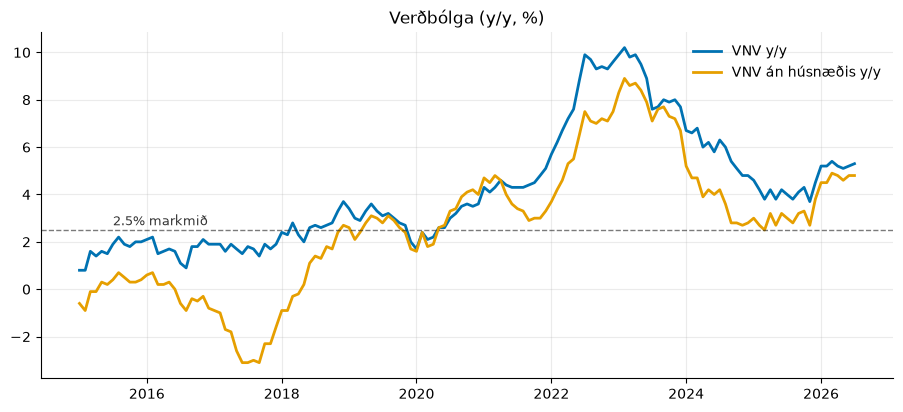

In [4]:
yy = head[("CPI", "change_A")]["2015":]
yy_lh = head[("CPILH", "change_A")]["2015":]
fig, ax = plt.subplots()
ax.plot(yy.index.to_timestamp(), yy, color=C["blue"], lw=2, label="VNV y/y")
ax.plot(yy_lh.index.to_timestamp(), yy_lh, color=C["orange"], lw=2, label="VNV án húsnæðis y/y")
ax.axhline(2.5, color=C["black"], lw=1, ls="--", alpha=0.6)
ax.annotate("2.5% markmið", xy=(yy.index.to_timestamp()[6], 2.7), fontsize=9, alpha=0.8)
ax.set_title("Verðbólga (y/y, %)")
ax.legend(frameon=False)
plt.show()


## The weights

Two kinds of weight exist and the difference matters:

1. **Basket weights (vogir, `VIS01306`)** — the December basket from the household
   expenditure survey, fixed quantities for the year, published **per 10 000**.
2. **Monthly price-updated weights (Vægi %, `VIS01300`/`VIS01301`)** — the same basket's
   *value shares at current prices*. These evolve every month as relative prices move and
   are the weights that actually enter each month's Laspeyres contribution identity:

$$\text{headline m/m} = \sum_i w_{i,t-1}\,g_{i,t}, \qquad w_{i,t-1} = \text{Vægi at } t-1$$

Notebook 02 verifies this identity against every published month. The forecast in
notebook 03 starts from the latest published Vægi and price-updates it along the path.


In [5]:
DIV = [f"CP{i:02d}" for i in range(1, 14)]
last_m = sub_new.manudur.max()
latest = sub_new[sub_new.manudur == last_m].set_index("code")

w_base = weights_new.set_index("code")["2025M12"] / 100  # per-10000 -> %
div_tbl = pd.DataFrame({
    "heiti": latest.loc[DIV, "heiti"],
    "vog des-2025 (%)": w_base[DIV],
    f"vægi {last_m} (%)": latest.loc[DIV, "vaegi"],
})
div_tbl["breyting (pp)"] = div_tbl.iloc[:, 2] - div_tbl.iloc[:, 1]
print(f"sums: basket {div_tbl.iloc[:, 1].sum():.2f} | current {div_tbl.iloc[:, 2].sum():.2f}")
div_tbl.round(2)


sums: basket 99.99 | current 100.01


,heiti,vog des-2025 (%),vægi 2026-07 (%),breyting (pp)
code,,,,
CP01,01 Matur og óáfengir drykkir,15.4400,15.2500,-0.1900
CP02,"02 Áfengir drykkir, tóbak og fíkniefni",2.4800,2.4700,-0.0100
CP03,03 Fatnaður og skófatnaður,3.6600,3.2900,-0.3700
CP04,"04 Húsnæði, vatn, rafmagn, gas og aðrir orkugj...",30.3000,30.0700,-0.2300
CP05,"05 Húsbúnaður, heimilistæki og þjónusta tengd ...",4.2100,3.9000,-0.3100
CP06,06 Heilsa,4.0100,3.9400,-0.0700
CP07,07 Flutningar,15.1500,16.4900,1.3400
CP08,08 Upplýsingar og fjarskipti,4.2800,4.3000,0.0200
CP09,"09 Afþreying, íþróttir og menning",9.1800,8.9800,-0.2000


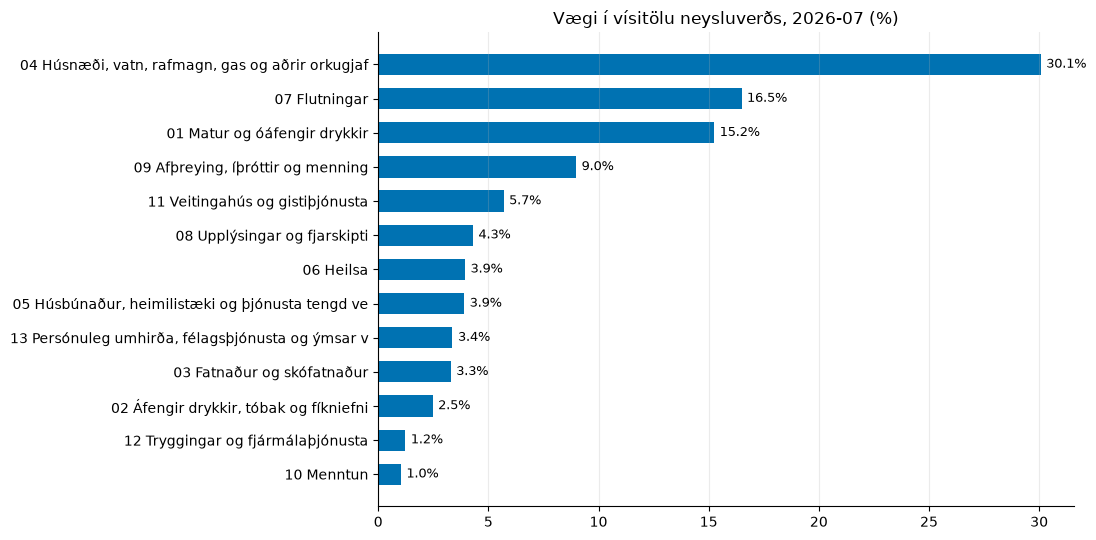

In [6]:
d = div_tbl.sort_values(f"vægi {last_m} (%)")
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(d.heiti.str.slice(0, 48), d[f"vægi {last_m} (%)"], color=C["blue"], height=0.62)
for i, v in enumerate(d[f"vægi {last_m} (%)"]):
    ax.text(v + 0.25, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_title(f"Vægi í vísitölu neysluverðs, {last_m} (%)")
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()


## Forecast components

The model works at division level with housing (CP04) split into its groups, so that
**reiknuð húsaleiga (CP042)** — the largest single component and the one with the
June-2024 methodology break — is modeled on its own regime.


In [7]:
from vnv import models

comp = latest.loc[models.COMPONENTS, ["heiti", "vaegi"]].rename(columns={"vaegi": f"vægi {last_m} (%)"})
assert abs(comp.iloc[:, 1].sum() - 100) < 0.05, "component weights must partition the basket"
print("component weights sum:", comp.iloc[:, 1].sum().round(2), "(17 non-overlapping components)")
comp.round(2)


component weights sum: 100.01 (17 non-overlapping components)


,heiti,vægi 2026-07 (%)
code,,
CP01,01 Matur og óáfengir drykkir,15.2500
CP02,"02 Áfengir drykkir, tóbak og fíkniefni",2.4700
CP03,03 Fatnaður og skófatnaður,3.2900
CP041,041 Greidd húsaleiga,3.6300
CP042,042 Reiknuð húsaleiga,20.7400
CP043,"043 Viðhald, viðgerðir og öryggi húsnæðis",1.0700
CP044,044 Vatnsveita og ýmis þjónusta tengd húsnæði,1.6500
CP045,"045 Rafmagn, gas og aðrir orkugjafar",2.9800
CP05,"05 Húsbúnaður, heimilistæki og þjónusta tengd ...",3.9000


## Anchor check — do the fetched weights reproduce the press-release figures?

`PLAN_1.md` quotes approximate implied weights from Hagstofa releases. The published
Vægi is price-updated and moves month to month (airfares' weight swings from 1.4% in
winter to 3.5% in July — that alone is a good sanity check that these are value shares,
not fixed weights). The test: each anchor must sit inside — or within ~1pp of — the range
its component's published weight actually took over 2025–2026.


In [8]:
anchor_rows = [
    ("matur og drykkur (CP01)", "CP01", 15.0),
    ("föt og skór (CP03)", "CP03", 3.6),
    ("húsbúnaður (CP05)", "CP05", 4.3),
    ("reiknuð húsaleiga (CP042)", "CP042", 21.7),
    ("flugfargjöld til útlanda (CP07332)", "CP07332", 2.55),
    ("bensín (CP07222)", "CP07222", 1.7),
    ("dísel (CP07221)", "CP07221", 0.8),
    ("gistiþjónusta (CP112)", "CP112", 0.6),
]
rows = []
for name, code, plan_val in anchor_rows:
    s = sub_new[sub_new.code == code].set_index("manudur").vaegi
    dist = max(0.0, s.min() - plan_val, plan_val - s.max())
    rows.append({"component": name, "plan anchor (%)": plan_val,
                 "vægi range 2025–26 (%)": f"{s.min():.2f} – {s.max():.2f}",
                 f"vægi {last_m} (%)": s[last_m], "distance to range (pp)": dist,
                 "status": "í bili" if dist == 0 else "nálægt"})
anchor_tbl = pd.DataFrame(rows).set_index("component")
assert anchor_tbl["distance to range (pp)"].max() < 1.0, "anchor severely off - wrong component mapping?"
anchor_tbl.round(2)


,plan anchor (%),vægi range 2025–26 (%),vægi 2026-07 (%),distance to range (pp),status
component,,,,,
matur og drykkur (CP01),15.0000,15.25 – 15.84,15.2500,0.2500,nálægt
föt og skór (CP03),3.6000,3.29 – 3.78,3.2900,0.0000,í bili
húsbúnaður (CP05),4.3000,3.90 – 4.89,3.9000,0.0000,í bili
reiknuð húsaleiga (CP042),21.7000,20.29 – 20.97,20.7400,0.7300,nálægt
flugfargjöld til útlanda (CP07332),2.5500,1.43 – 3.52,3.5200,0.0000,í bili
bensín (CP07222),1.7000,1.67 – 2.71,1.7500,0.0000,í bili
dísel (CP07221),0.8000,0.77 – 1.04,0.8100,0.0000,í bili
gistiþjónusta (CP112),0.6000,0.61 – 0.85,0.7800,0.0100,nálægt


Six of eight anchors fall inside the observed weight range. The two marked *nálægt*
are explained by basket vintage: the plan quotes ~15.0% for food and ~21.7% for imputed
rent from earlier releases/approximations (`PLAN_1.md` §1.1 itself says "~21–22%");
the COICOP2018 December-2025 basket puts them at 15.44% and 20.88%. The component
identification is unambiguous in every case.

## The June-2024 break in reiknuð húsaleiga

Weight history of imputed rent: old classification (IS042) until 2024, COICOP2018 (CP042)
from 2025. The June-2024 switch from user cost to rental equivalence *changed the
data-generating process*, which is why notebook 03 fits this component on post-break data only.


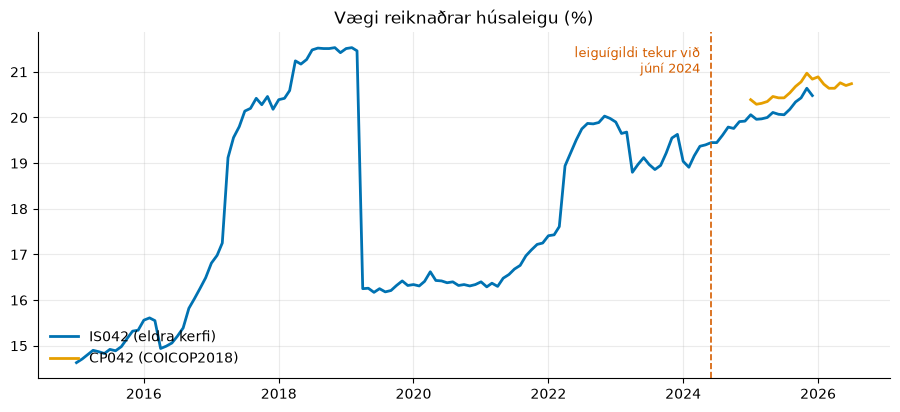

In [9]:
w_old = panel_old[panel_old.code == "IS042"].set_index("manudur").vaegi["2015":]
w_new_s = sub_new[sub_new.code == "CP042"].set_index("manudur").vaegi
fig, ax = plt.subplots()
ax.plot(w_old.index.to_timestamp(), w_old, color=C["blue"], lw=2, label="IS042 (eldra kerfi)")
ax.plot(w_new_s.index.to_timestamp(), w_new_s, color=C["orange"], lw=2, label="CP042 (COICOP2018)")
brk = pd.Period("2024-06", "M").to_timestamp()
ax.axvline(brk, color=C["red"], lw=1.2, ls="--")
ax.annotate("leiguígildi tekur við\njúní 2024", xy=(brk, w_old.max()), fontsize=9,
            color=C["red"], ha="right", xytext=(-8, -18), textcoords="offset points")
ax.set_title("Vægi reiknaðrar húsaleigu (%)")
ax.legend(frameon=False, loc="lower left")
plt.show()
